In [28]:
import pandas as pd
import matplotlib.pyplot as pl
from importlib import reload
import numpy as np
import corner
import sys
sys.path.append('/mnt/zfsusers/hollowayp/paltas/')
try: reload(sys.modules['parameter_dicts'])
except: pass
from parameter_dicts import truth_range_dict,title_dict,bin_dict,units_dict,Error_range_dict

data_folder = '/mnt/extraspace/hollowayp/paltas_data/Example_LP_23'# For lens-light subtracted
# data_folder = '/mnt/extraspace/hollowayp/paltas_data/Example_LP_21_no_subtr_LS_light' #For no subtraction

### Comparison of Test + Training Sets

In [18]:
db_test = pd.read_csv(f'{data_folder}/test_metadata_val.csv')
db_mu = pd.read_csv(f'{data_folder}/test_network_pred_mu_db.csv')
db_std = pd.read_csv(f'{data_folder}/test_network_std_db.csv')

db_test_metadata = pd.read_csv(f'{data_folder}/test/metadata.csv')
db_test=db_test.drop(columns=['Unnamed: 0','main_deflector_parameters_gamma'])
db_test=pd.merge(db_test,db_test_metadata,on=['main_deflector_parameters_theta_E',
                                              'main_deflector_parameters_gamma1',
                                              'main_deflector_parameters_gamma2',
                                              'main_deflector_parameters_e1',
                                              'main_deflector_parameters_e2',
                                              'main_deflector_parameters_center_y',
                                              'main_deflector_parameters_center_x',
                                            #   'lens_light_parameters_mag_app',
                                            #   'source_parameters_R_sersic',
                                            #   'source_parameters_mag_app'
                                              ])
# db_test.to_csv('/mnt/zfsusers/hollowayp/paltas_test_set_metadata.csv')
db_train = pd.read_csv(f'{data_folder}/training/2/metadata.csv')

db_OM10_test = pd.read_csv('/mnt/zfsusers/hollowayp/Padma_OM10_test_set_metadata.csv')

(array([1183., 1884., 2335., 2046., 1389.,  772.,  282.,   89.,   17.,
           3.]),
 array([7.71419411e-05, 1.48414021e-01, 2.96750900e-01, 4.45087779e-01,
        5.93424658e-01, 7.41761537e-01, 8.90098416e-01, 1.03843529e+00,
        1.18677217e+00, 1.33510905e+00, 1.48344593e+00]),
 <BarContainer object of 10 artists>)

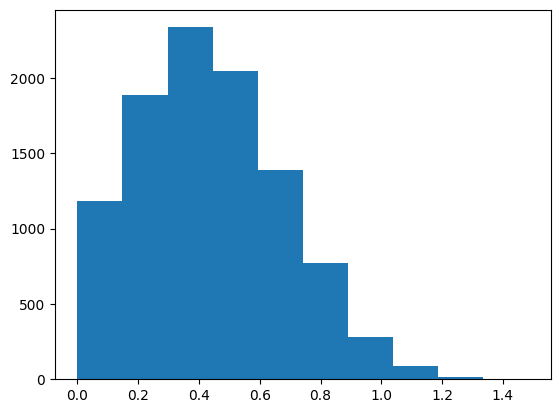

In [21]:
from scipy.stats import truncnorm
pl.hist(truncnorm(-1.4217,np.inf,loc=0.3951,scale=0.2779).rvs(10000))

In [19]:
db_train[columns_to_plot].describe().loc['std'],

(main_deflector_parameters_theta_E    0.453945
 main_deflector_parameters_z_lens     0.243632
 source_parameters_z_source           0.898230
 lens_light_parameters_mag_app        2.096822
 source_parameters_mag_app            1.242599
 source_parameters_R_sersic           0.241432
 Name: std, dtype: float64,)

In [17]:
db_test[columns_to_plot].describe().loc['std']

main_deflector_parameters_theta_E    0.379498
main_deflector_parameters_z_lens     0.231271
source_parameters_z_source           0.890546
lens_light_parameters_mag_app        1.751681
source_parameters_mag_app            1.038118
source_parameters_R_sersic           0.230071
Name: std, dtype: float64

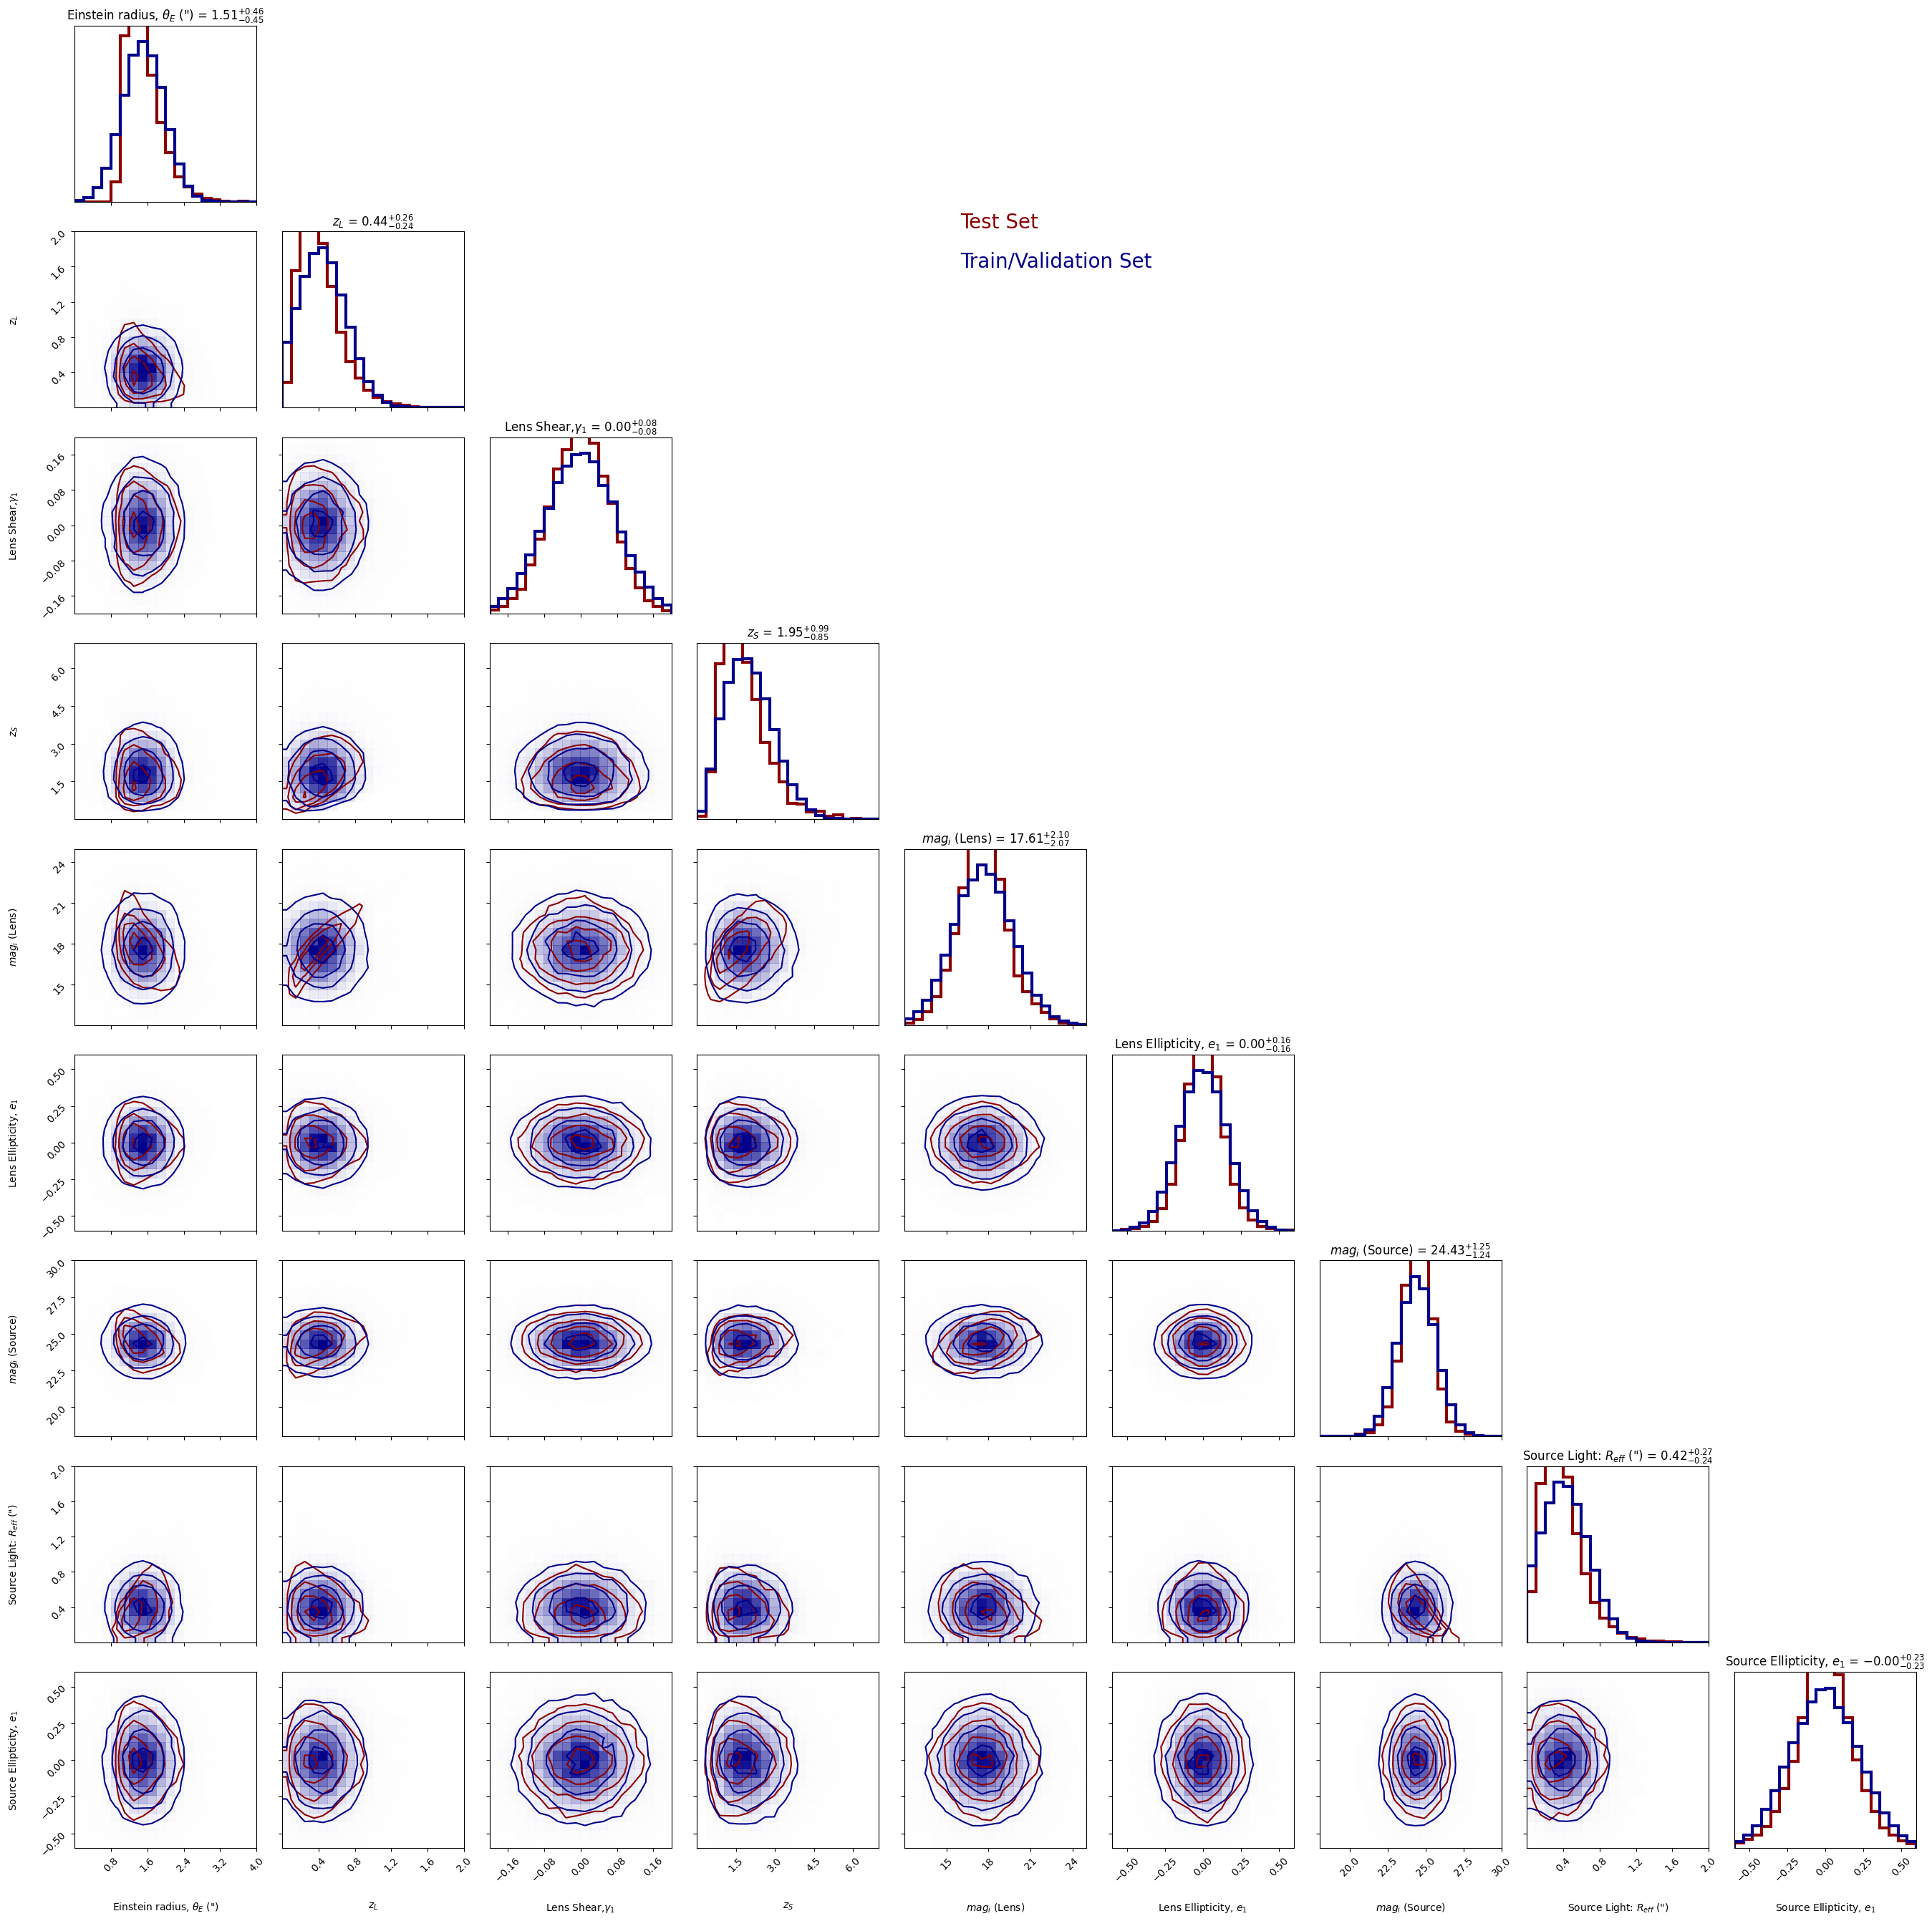

In [33]:
columns_to_plot = ['main_deflector_parameters_theta_E',
                   'main_deflector_parameters_z_lens',
                   'main_deflector_parameters_gamma1',
                   'source_parameters_z_source',
                   'lens_light_parameters_mag_app',
                   'main_deflector_parameters_e1',
                   'source_parameters_mag_app',
                   'source_parameters_R_sersic',
                   'source_parameters_e1'
                   ]

# levels = 1-np.array([1 - np.exp(-(2**2)/2),#% Contained within 2,1 sigma (have to do 1- as the levels does fraction *below* contour)
#                      1 - np.exp(-(1**2)/2),# => See https://corner.readthedocs.io/en/latest/pages/sigmas/ for why this equation is used.
#                      0]) 

fig = pl.figure(figsize=(3*len(columns_to_plot),3*len(columns_to_plot)))
corner_dict = {'range':[truth_range_dict[elem] for elem in columns_to_plot],
                'labels':[title_dict[elem] for elem in columns_to_plot],
                'fig':fig,
                'show_titles':True}

corner.corner(db_test[columns_to_plot],color='darkred',hist_kwargs={'density':True,'linewidth':3},
            plot_datapoints=False,**corner_dict)
corner.corner(db_train[columns_to_plot],color='darkblue',hist_kwargs={'density':True,'linewidth':3},
            plot_datapoints=False,**corner_dict)
# corner.corner(db_OM10_test[columns_to_plot],color='darkgreen',hist_kwargs={'density':True,'linewidth':3},**corner_dict)
# corner.corner(db_OM10_test[db_OM10_test['main_deflector_parameters_theta_E']>0.9][columns_to_plot],color='darkorange',
#             hist_kwargs={'density':True,'linewidth':3},**corner_dict)

pl.tight_layout()
# fig.text(0.5,0.9,'OM10',size=20,color='darkgreen')
# fig.text(0.5,0.88,'OM10 ($\\theta_E>0.9$")',size=20,color='darkorange')
# fig.text(0.5,0.86,'LensPop',size=20,color='darkred')

fig.text(0.5,0.88,'Test Set',size=20,color='darkred')
fig.text(0.5,0.86,'Train/Validation Set',size=20,color='darkblue')
for fmt in ['pdf','png']: pl.savefig(f'/mnt/zfsusers/hollowayp/Documents/project_2/summary_plots/Train_test_corner_plots.{fmt}')
pl.show()

### Recovery Plots

In [ ]:
Precision = median(uncertainty/truth) #= Fractional Uncertainty
Scatter = median(abs_error/truth) #= Fractional Median Error
Mean_Error = mean((pred-truth)/truth) (Not absolute) # Fractional Mean Error

#For ones centered on zero, don't divide by truth.

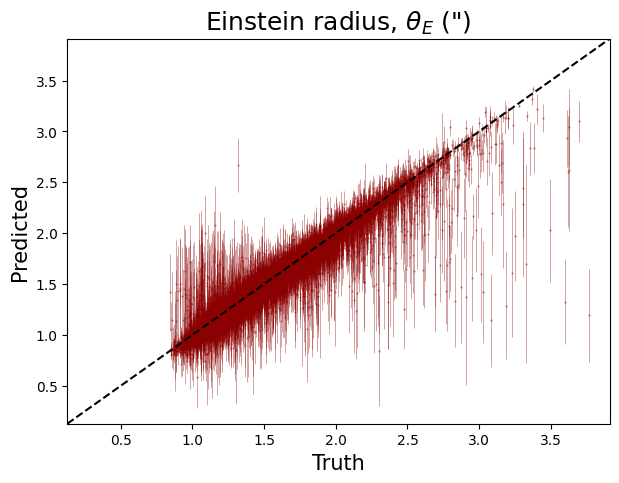

In [34]:
def plot_recovery_plot(truth,pred_mu,pred_std,title=None,color='darkred',return_fig=False,fig=None,ax=None):
    if not return_fig: fig,ax = pl.subplots(1,1,figsize=(7,5))
    ax.errorbar(truth,pred_mu,yerr=pred_std,fmt='.',alpha=0.5,linewidth=0.5,markersize=1,color=color)
    ax.set_xlabel('Truth',fontsize=15)
    ax.set_ylabel('Predicted',fontsize=15)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax.set_xlim([min(xlim[0],ylim[0]),max(xlim[1],ylim[1])])
    ax.set_ylim([min(xlim[0],ylim[0]),max(xlim[1],ylim[1])])
    ax.plot(ax.get_xlim(),ax.get_xlim(),ls='--',color='black',zorder=5)
    if title is not None: 
        ax.set_title(title_dict[title],fontsize=18)
        ax.set_xlabel(f'Truth',fontsize=15)
        ax.set_ylabel(f'Predicted',fontsize=15)
    y0=0.8;dy = 0.05
    # units = units_dict[title].replace('(','').replace(')','')
    # fig.text(0.2,y0,f'MAE: {np.round(np.mean(abs(pred_mu-truth)),3)}{units} = {np.round(np.mean(abs(pred_mu-truth)/pred_std),3)}$\sigma$',size=12,color='k')
    # fig.text(0.2,y0-dy,f'Median Uncertainty: {np.round(np.median(pred_std),3)}{units}',size=12,color='k')
    if not return_fig: pl.show()

for param in ['main_deflector_parameters_theta_E']:#,'main_deflector_parameters_gamma']:
    plot_recovery_plot(db_test[param], db_mu[param], db_std[param], param)

In [32]:
db_OM10_all_light = pd.read_csv('/mnt/users/hollowayp/Padma_OM10_paltas_input_output_all_light.csv')
db_OM10_all_subtr = pd.read_csv('/mnt/users/hollowayp/Padma_OM10_paltas_input_output_lens_and_AGN_subtr.csv')

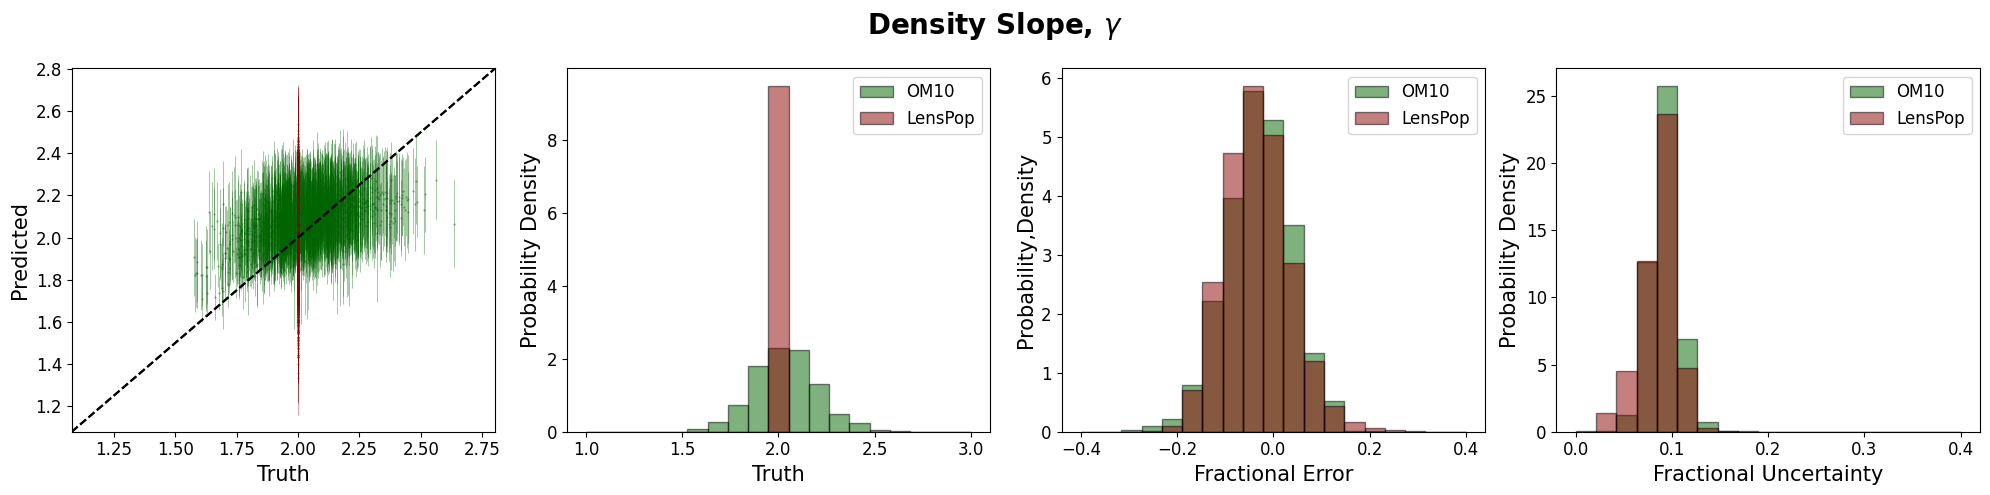

In [35]:
fig,ax = pl.subplots(1,4,figsize=(20,5))
ax_scat = 0
ax_true = 1
ax_Err = 2
ax_Unc = 3

param = 'main_deflector_parameters_gamma' #main_deflector_parameters_theta_E

db_OM10 = db_OM10_all_light
plot_recovery_plot(db_test[param],
                db_mu[param],
                db_std[param],
                return_fig=True,fig=fig,ax=ax[ax_scat])
plot_recovery_plot(db_OM10[param],
                   db_OM10[f'{param}_pred'],
                   db_OM10[f'{param}_stdpred'],
                   return_fig=True,fig=fig,ax=ax[ax_scat],color='darkgreen')

Error_OM10 = (db_OM10[param]-db_OM10[f'{param}_pred'])/db_OM10[param]
Error_LensPop = (db_test[param]-db_mu[param])/db_test[param]

Uncertainty_OM10 = db_OM10[f'{param}_stdpred']/db_OM10[param]
Uncertainty_LensPop = db_std[param]/db_test[param]

Truth_dict = {'bins':np.linspace(*truth_range_dict[param],20),'alpha':0.5,'density':True,'edgecolor':'k'}
ax[ax_true].hist(db_OM10[param],color='darkgreen',label='OM10',**Truth_dict)
ax[ax_true].hist(db_test[param],color='darkred',label='LensPop',**Truth_dict)
ax[ax_true].set_xlabel('Truth',size=15)
ax[ax_true].set_ylabel('Probability Density',size=15)

Error_dict = {'bins':np.linspace(*Error_range_dict[param],20),'alpha':0.5,'density':True,'edgecolor':'k'}
ax[ax_Err].hist(Error_OM10,label='OM10',color='darkgreen',**Error_dict)
ax[ax_Err].hist(Error_LensPop,label='LensPop',color='darkred',**Error_dict)
ax[ax_Err].set_xlabel('Fractional Error',size=15)
ax[ax_Err].set_ylabel('Probability,Density',size=15)
Uncertainty_dict = {'bins':np.linspace(0,Error_range_dict[param][1],20),'alpha':0.5,'density':True,'edgecolor':'k'}
ax[ax_Unc].hist(Uncertainty_OM10,color='darkgreen',label='OM10',**Uncertainty_dict)
ax[ax_Unc].hist(Uncertainty_LensPop,color='darkred',label='LensPop',**Uncertainty_dict)
ax[ax_Unc].set_xlabel('Fractional Uncertainty',size=15)
ax[ax_Unc].set_ylabel('Probability Density',size=15)
for p_i in [0,1,2,3]:
    if p_i>0: ax[p_i].legend(fontsize=12)
    ax[p_i].tick_params(labelsize=12)

pl.suptitle(title_dict[param],size=20,fontweight='bold')
pl.tight_layout()
pl.show()

# pd.DataFrame({'Precision':[np.median(Uncertainty_OM10),np.median(Uncertainty_LensPop)], #Fractional Uncertainty
#               ''})

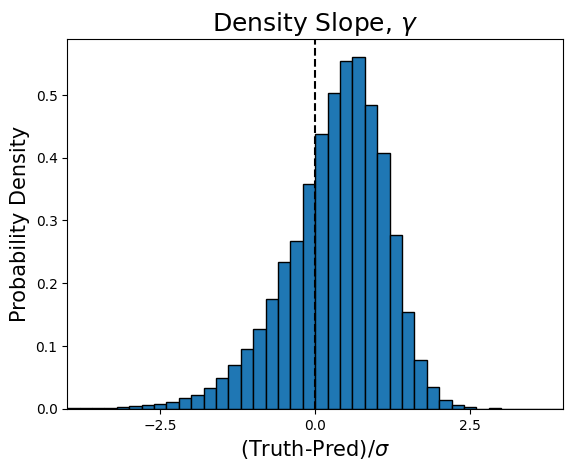

In [52]:
pl.hist((db_mu['main_deflector_parameters_gamma']-db_test['main_deflector_parameters_gamma'])/\
        db_std['main_deflector_parameters_gamma'],bins=np.linspace(-5,5,51),edgecolor='k',density=True)
pl.xlabel('(Truth-Pred)/$\sigma$',size=15)
pl.ylabel('Probability Density',size=15)
pl.title(title_dict['main_deflector_parameters_gamma'],fontsize=18)
pl.ylim(pl.ylim())
pl.xticks([-2.5,0,2.5])
pl.xlim(-4,4)
pl.plot([0,0],pl.ylim(),'k--',zorder=4)
pl.show()

### Cutout Collage

Will use interval/stretch of ('zscale', 'sqrt') and vmin/vmax of (0, 60)
Plotting from npy files


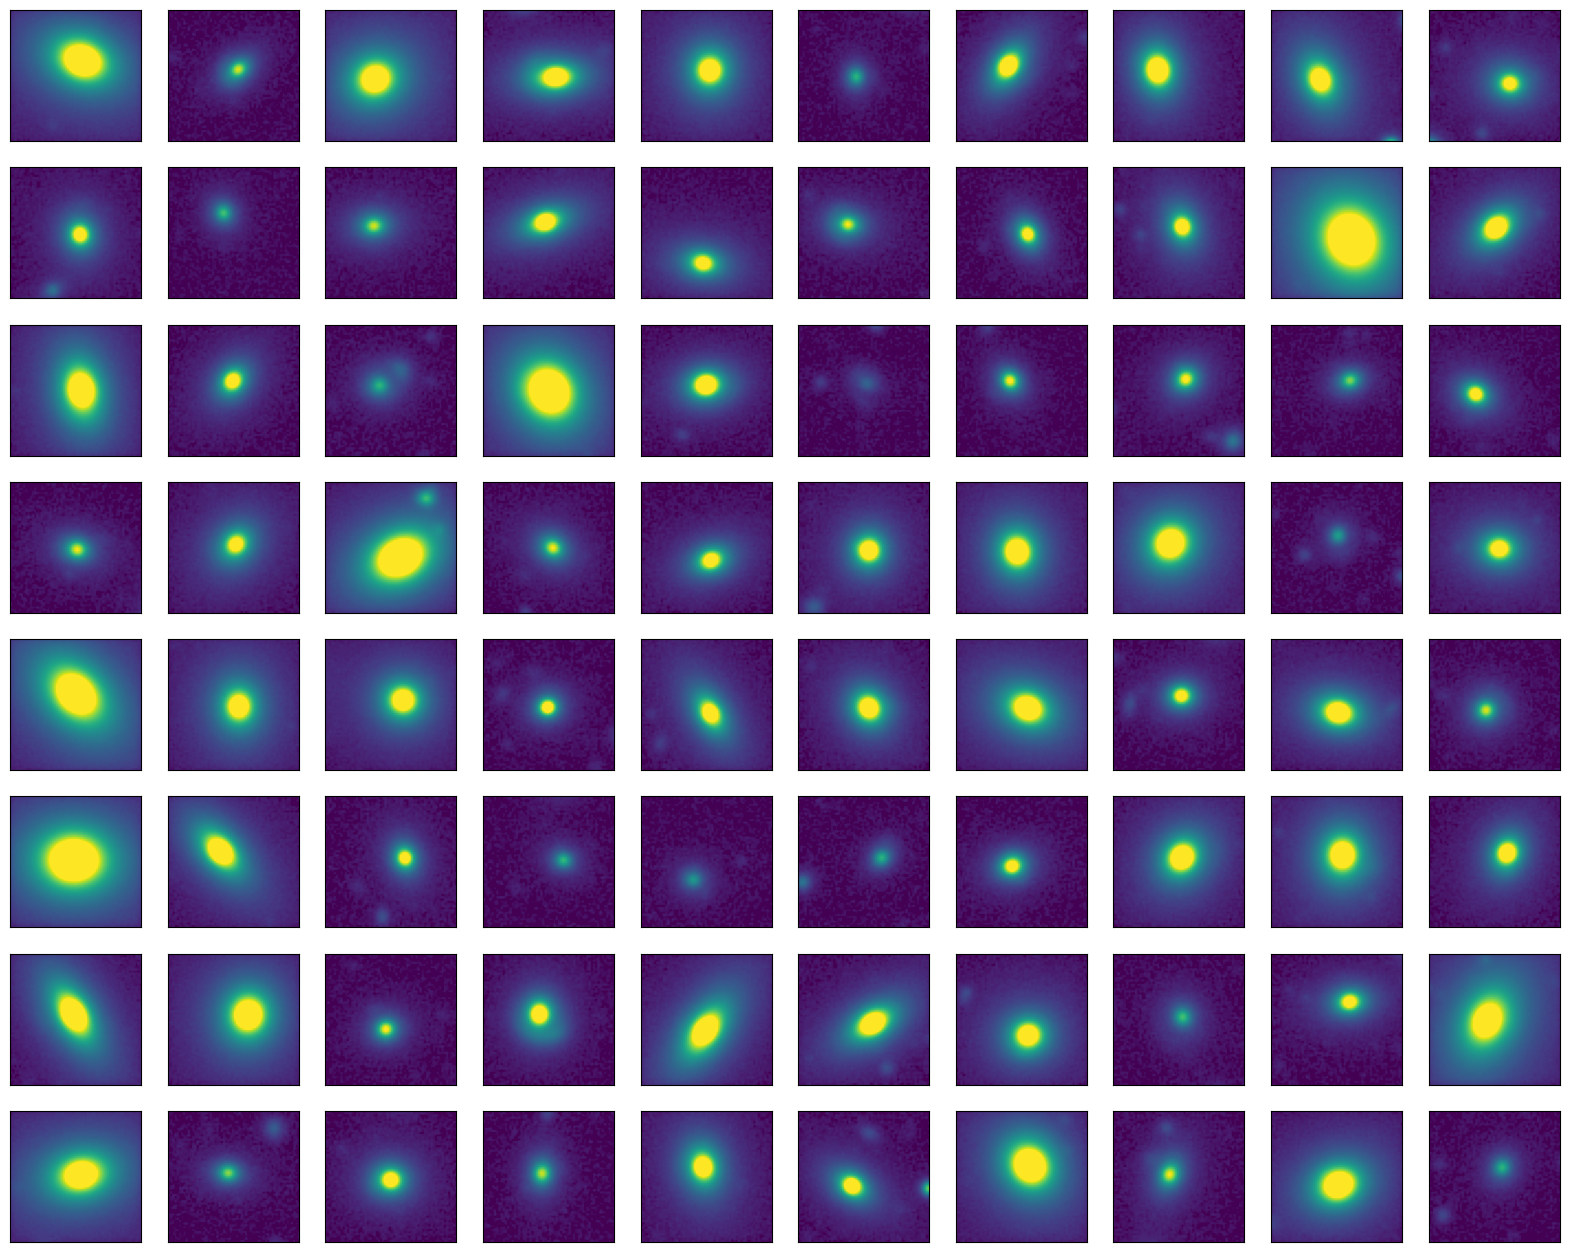

In [131]:
from plot_image_collage import plot_collage

plot_collage('/mnt/extraspace/hollowayp/paltas_data/Example_LP_21_no_subtr_LS_light/test',N_rows=8,N_cols=10,interval='zscale',stretch='sqrt',
            #  vmin=0,vmax=2.5,figsize=(20,16),tight_layout=False)
             vmin=0,vmax=60,figsize=(20,16),tight_layout=False)

In [22]:
from load_h5_file import load_h5_file

In [25]:
a = load_h5_file('/mnt/zfsusers/hollowayp/paltas/RSP_Coadd_Files_100000/0_Nexp_data.h5')

(array([2.67000e+02, 2.50000e+01, 1.60000e+01, 1.40000e+01, 2.40000e+01,
        2.50000e+01, 3.50000e+01, 3.20000e+01, 4.30000e+01, 7.30000e+01,
        9.20000e+01, 1.30000e+02, 2.38000e+02, 3.46000e+02, 5.95000e+02,
        1.74680e+04, 2.23988e+05, 8.98518e+05, 6.04844e+05, 5.32270e+04]),
 array([  0.  ,   6.25,  12.5 ,  18.75,  25.  ,  31.25,  37.5 ,  43.75,
         50.  ,  56.25,  62.5 ,  68.75,  75.  ,  81.25,  87.5 ,  93.75,
        100.  , 106.25, 112.5 , 118.75, 125.  ]),
 <BarContainer object of 20 artists>)

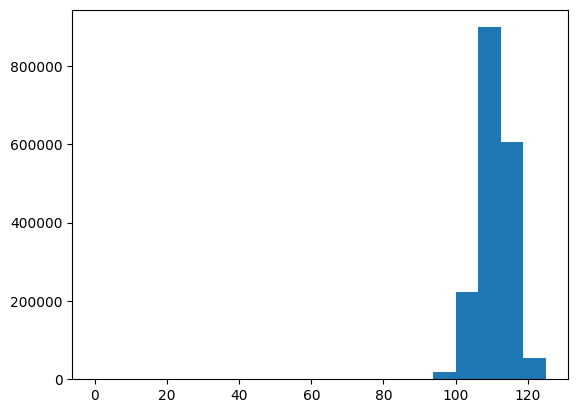

In [28]:
pl.hist(a.flatten(),bins=20)

In [29]:
pd.read_csv('/mnt/zfsusers/hollowayp/paltas/datasets/LensPop_databases/LensPop_LSST_Paltas_Catalogue_0.csv')

,Unnamed: 0,index,zL,zS,seeing,sig_v,xs,ps,Re_source,pf,...,defl_light_y,defl_gamma,defl_e1_mass,defl_e2_mass,defl_e1_light,defl_e2_light,defl_gamma1,defl_gamma2,defl_Ns,source_Ns
0,0,0,0.333763,1.1528,1.39802,321.256960,-0.252556,20.608003,0.880695,True,...,0.849126,2,0.071780,-0.056696,0.071780,-0.056696,0.014559,0.135619,4,1
1,1,3,0.089578,1.0012,1.39802,290.321611,0.448867,20.685148,0.996384,True,...,2.116176,2,-0.009610,0.070525,-0.009610,0.070525,0.048398,0.037825,4,1
2,2,4,0.351007,2.2672,1.39802,285.841309,0.750827,159.419567,0.731373,True,...,0.207937,2,0.232306,0.009571,0.232306,0.009571,-0.021727,0.069958,4,1
3,3,7,0.474017,1.6582,1.39802,274.231133,0.484866,21.133561,0.575830,True,...,0.357355,2,-0.071797,0.146835,-0.071797,0.146835,0.090296,-0.013185,4,1
4,4,8,0.285569,1.4486,1.39802,280.360559,-0.940516,4.895083,0.736641,True,...,0.909808,2,-0.066533,0.043112,-0.066533,0.043112,-0.149246,-0.021363,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24244,24244,50700,0.762405,2.7563,1.91859,299.947219,0.102793,99.396234,0.549181,True,...,0.249000,2,0.075552,0.125886,0.075552,0.125886,-0.102158,-0.047254,4,1
24245,24245,50701,0.302091,2.8443,1.91859,226.704388,-0.118618,98.990674,0.503767,True,...,0.300186,2,0.101968,0.229123,0.101968,0.229123,0.048079,-0.054771,4,1
24246,24246,50702,0.304098,1.2929,1.91859,313.986751,-0.082432,158.692965,0.145820,True,...,1.291933,2,0.132209,0.205915,0.132209,0.205915,-0.016082,-0.022902,4,1
24247,24247,50704,0.316001,1.6059,1.91859,361.374505,0.117218,61.930178,1.078451,True,...,0.860087,2,0.075895,0.004303,0.075895,0.004303,-0.133265,0.042322,4,1
